# Customer Segmentation Analysis

### Libraries

In [82]:
!pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [83]:
df = pd.read_csv(r"C:\Users\sebas\OneDrive\Ambiente de Trabalho\customer-segmentation-analysis\data\Mall_Customers.csv")

In [84]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [85]:
df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [86]:
df.rename(columns={'Annual Income (k$)': 'Annual Income'}, inplace=True)

In [87]:
df.rename(columns={'Spending Score (1-100)': 'Spending Score'}, inplace=True)

In [88]:
df.rename(columns={'Genre': 'Gender'}, inplace=True)

In [89]:
df = df.drop('CustomerID', axis=1)

Categoric Variables

In [90]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

Numeric variables

In [91]:
df.describe()

,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


Important notes
- Age ranges between 18 and 70 years old.
- Annual income of the customers range between 15k and 137k. | std = 26
- Mall atributed scores from 1 to 100 to the custoners, based on their spending levels.
- Females > Males

### Exploratory Data Analysis

#### 1.1. Outliers
- No outliers found except for Annual Income.

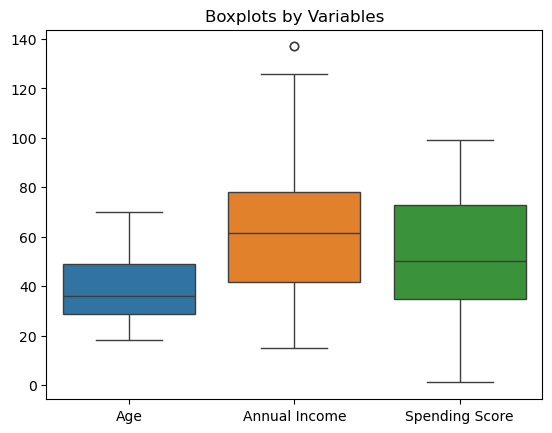

In [92]:
sns.boxplot(df)
plt.title("Boxplots by Variables")
plt.show()

##### - Log transformation
- In this case not so effective, best approach could be identifying and removing outliers by boxplots.

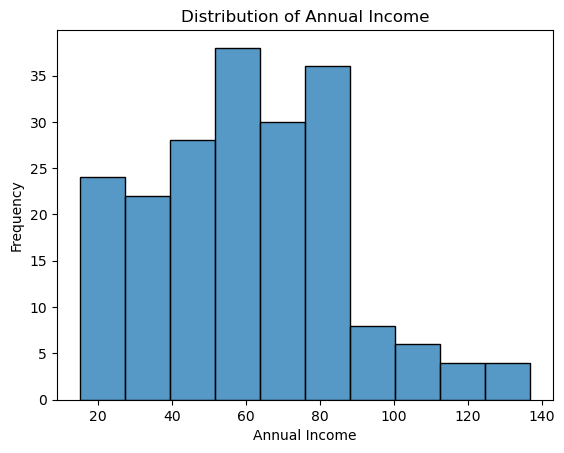

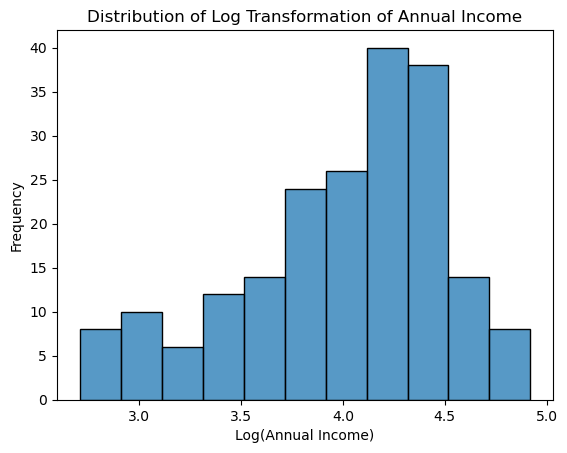

In [93]:
sns.histplot(df['Annual Income'])
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.show()
sns.histplot(np.log(df['Annual Income']))
plt.title('Distribution of Log Transformation of Annual Income')
plt.xlabel('Log(Annual Income)')
plt.ylabel('Frequency')
plt.show()

In [94]:
Q1 = df['Annual Income'].quantile(0.25)
Q3 = df['Annual Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Annual Income'] < lower) | (df['Annual Income'] > upper)]
outliers

,Gender,Age,Annual Income,Spending Score
198,Male,32,137,18
199,Male,30,137,83


In [95]:
df_clean = df[(df['Annual Income'] >= lower) & (df['Annual Income'] <= upper)]

In [96]:
df.shape
df_clean.shape

(198, 4)

#### 1.2. Distributions Analysis of Categoric Variables

To better understand the behavioral patterns, we decide to group age, income, and spending score into categoric variables. 
This variables won't be used in modelling, but will be essential to EDA and to define the final segments.

In [97]:
bins = [18, 25, 35, 45, 55, 70]
labels = ['18-25', '26-35', '36-45', '46-55', '56-70']
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, include_lowest=True)

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\3257566111.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, include_lowest=True)


In [98]:
bins   = [15, 40, 70, 100, 145]
labels = ['Low', 'Medium', 'High', 'Very High']

df_clean['IncomeGroup'] = pd.cut(df_clean['Annual Income'], bins=bins, labels=labels, include_lowest=True)

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\299530557.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['IncomeGroup'] = pd.cut(df_clean['Annual Income'], bins=bins, labels=labels, include_lowest=True)


In [99]:
df_clean['SpendingGroup'] = pd.cut(df_clean['Spending Score'], bins=[0, 25, 50, 75, 100], labels=['Very Low','Low','High','Very High'], include_lowest=True)

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\1990786908.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['SpendingGroup'] = pd.cut(df_clean['Spending Score'], bins=[0, 25, 50, 75, 100], labels=['Very Low','Low','High','Very High'], include_lowest=True)


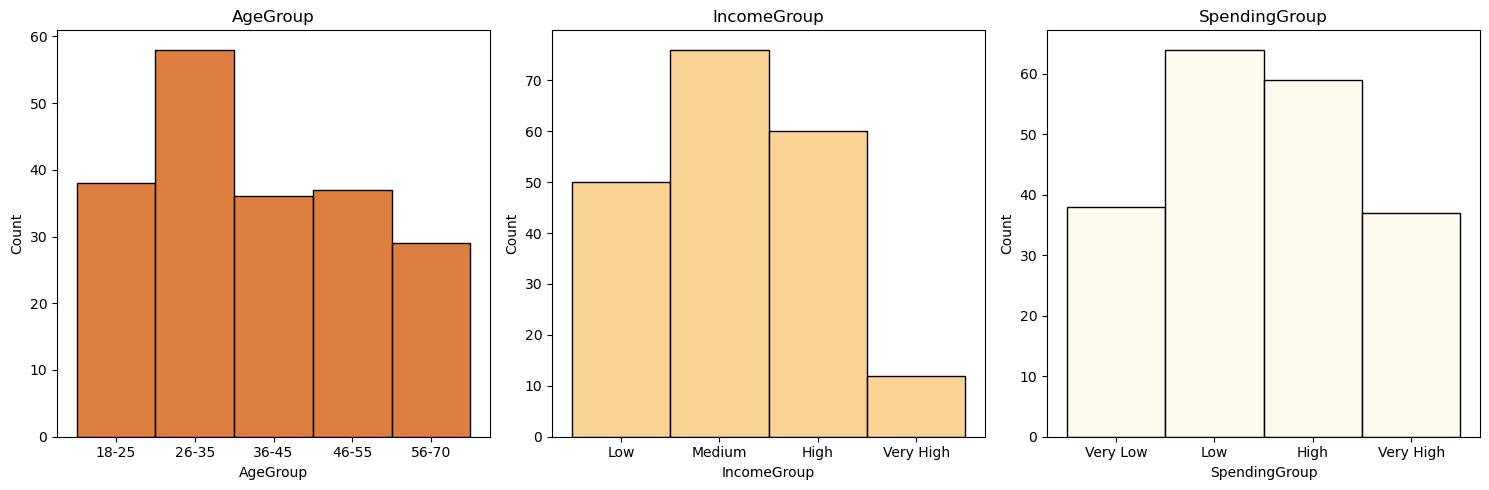

In [100]:
cols = ['AgeGroup', 'IncomeGroup', 'SpendingGroup']
colors = ["#D35400", "#F8C471", "#FEF9E7"]

fig, axes = plt.subplots(1, len(cols), figsize=(15, 5))

for i, col in enumerate(cols):
    sns.histplot(df_clean[col], ax=axes[i], color=colors[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\2645079637.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_means = df_clean.groupby('AgeGroup')['Annual Income'].mean().reindex(age_order)
C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\2645079637.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spend_means  = df_clean.groupby('AgeGroup')['Spending Score'].mean().reindex(age_order)
C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\2645079637.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `l

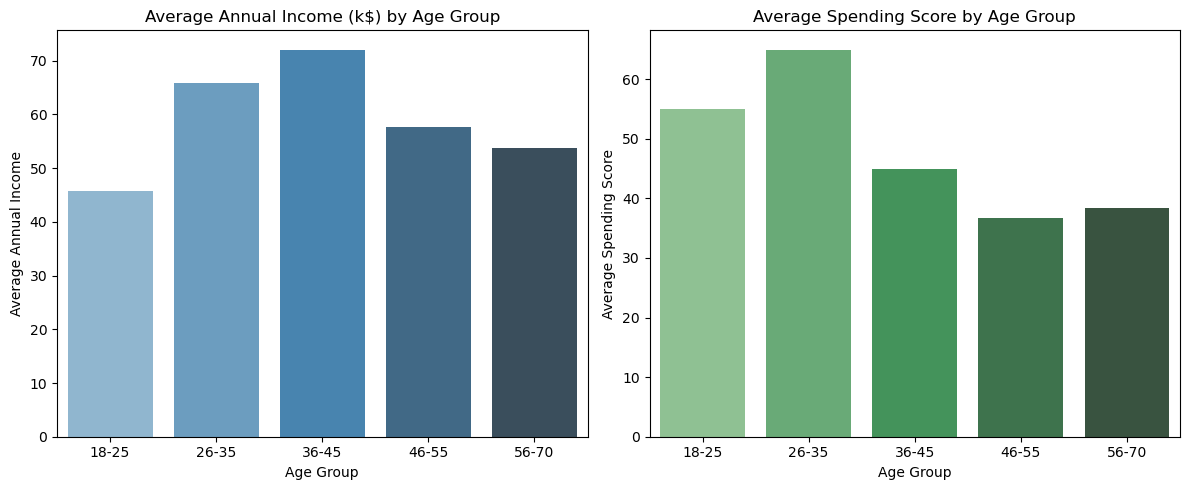

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

age_order = ['18-25', '26-35', '36-45', '46-55', '56-70']
income_means = df_clean.groupby('AgeGroup')['Annual Income'].mean().reindex(age_order)
spend_means  = df_clean.groupby('AgeGroup')['Spending Score'].mean().reindex(age_order)

#For the Annual Income
sns.barplot(x=income_means.index, y=income_means.values, ax=axes[0], palette='Blues_d')
axes[0].set_title('Average Annual Income (k$) by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Average Annual Income')

#For the Spending Score
sns.barplot(x=spend_means.index, y=spend_means.values, ax=axes[1], palette='Greens_d')
axes[1].set_title('Average Spending Score by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Spending Score')

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

- As expected, customers between the ages 26-35 and 36-45 own higher income levels. 

- However, by the 2nd graph only spending score of the age group 26-35 is in accordance with the high income level. 

    -- High annual income -> High Spending Score

- Young adults tend to spend more, despite having lower income levels. 

- Opportunity to retain customers from 36 to 70 since they have a higher income power and do not spend that much.

In [102]:
df_clean.groupby('AgeGroup')['Spending Score'].mean() 

C:\Users\sebas\AppData\Local\Temp\ipykernel_10500\1872160281.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('AgeGroup')['Spending Score'].mean()


AgeGroup
18-25    54.947368
26-35    64.931034
36-45    44.833333
46-55    36.702703
56-70    38.379310
Name: Spending Score, dtype: float64

In [103]:
#df.groupby(['AgeGroup', 'IncomeGroup']).size()

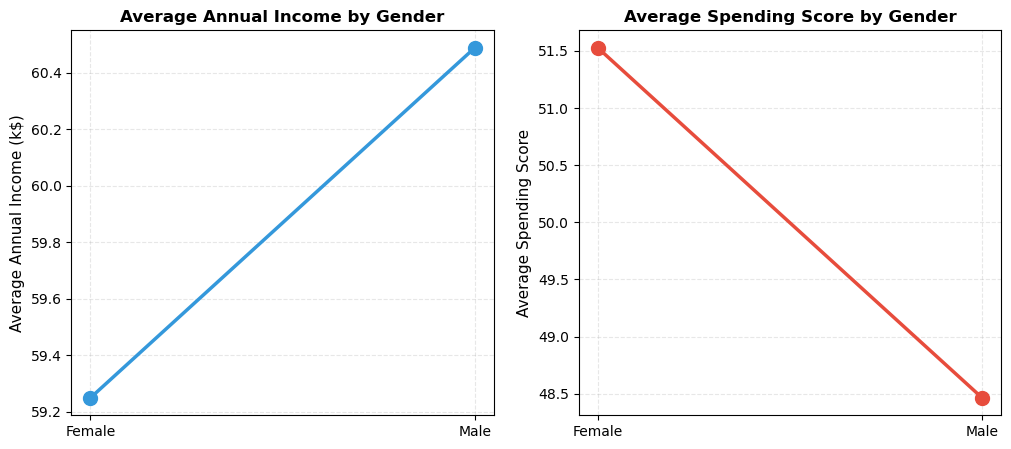

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

grouped_income = df_clean.groupby('Gender')['Annual Income'].mean()
grouped_spending = df_clean.groupby('Gender')['Spending Score'].mean()

# Income
axes[0].plot(grouped_income.index, grouped_income.values, marker='o', color='#3498db', linewidth=2.5, markersize=10)
axes[0].set_title('Average Annual Income by Gender', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Annual Income (k$)', fontsize=11)
axes[0].grid(alpha=0.3, linestyle='--')

# Spending Score
axes[1].plot(grouped_spending.index, grouped_spending.values, marker='o', color='#e74c3c', linewidth=2.5, markersize=10)
axes[1].set_title('Average Spending Score by Gender', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Spending Score', fontsize=11)
axes[1].grid(alpha=0.3, linestyle='--')

plt.show()

**Expected behavior**: *Higher Average Annual Income -> Higher Spending Score*

**Reality**: 
- Average Annual Income is higher in males, but Spending Score lower.
- Average Annual Income is lower in females, but Spending Score is higher.

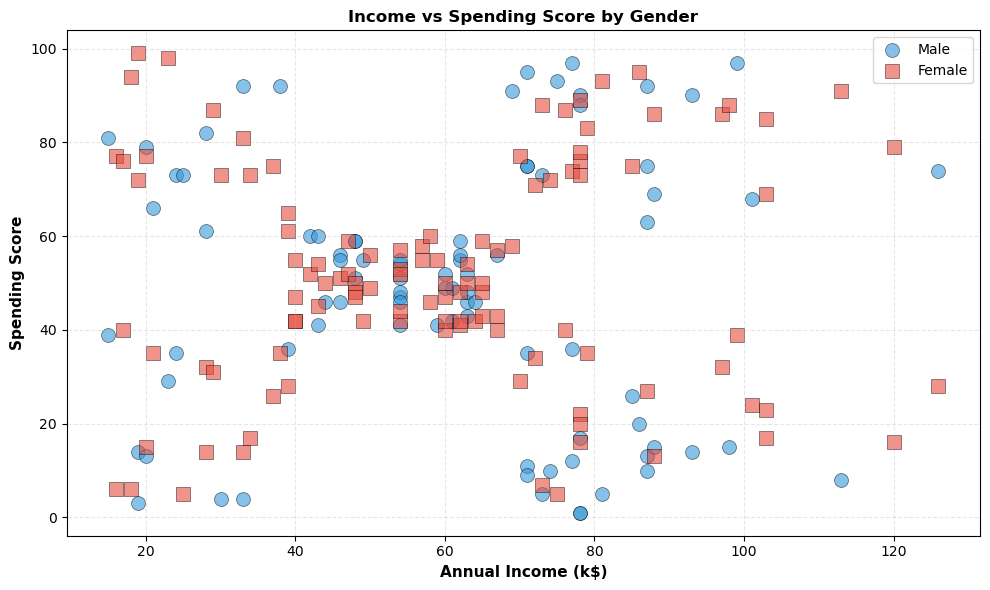

In [116]:
markers = {"Male": "o", "Female": "s"}
colors = {"Male": "#3498db", "Female": "#e74c3c"}

plt.figure(figsize=(10, 6))

for gender, marker in markers.items():
    subset = df_clean[df_clean['Gender'] == gender]
    plt.scatter(subset['Annual Income'],
                subset['Spending Score'],
                label=gender,
                marker=marker,
                s=100,
                alpha=0.6,
                color=colors[gender],
                edgecolors='black',
                linewidth=0.5)

plt.xlabel('Annual Income (k$)', fontsize=11, fontweight='bold')
plt.ylabel('Spending Score', fontsize=11, fontweight='bold')
plt.title('Income vs Spending Score by Gender', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### Insights 

Through a first analysis it was possible to state that:
- Ages range bewteen 18y and 70y;
- Annual Income range between 15k and 137k;
- Attributed spending score to the customers is from 1 and 100.
- Mall customers are mainly composed by females.

Diving deeper into **1. EDA**:

**1.1. Outliers**

- Outliers found for *Annual Income*. *Annual Income* presented a right sweked distribution, and log-transformation was applied to correct it. As this was not effective as expective, decided to remove those outliers since it would not have a big impact on the size of our data set.

**1.2. Distribution Analysis of Categoric Variables**

- Adding Categoric Variables: To better understand the behavioral patterns, we decide to group *Age*, *Annual Income*, and *Spending Score* into categoric variables. This variables won't be used in modelling, but were essential to EDA.

- Majority of the mall customers are 2) within the 26-35 age group, 3) own high income levels, 4) have low to high spending scores.

- As expected, customers between the ages 26-35 and 36-45 own higher *Annual Income* levels. 

- However, it was expected that:

    **High Annual Income -> High Spending Score**

    **Reality:**
    
    - Only *Spending Score* of the age group 26-35 is in accordance with the high income level of that group. 
    - Young adults (18-26) tend to spend more, despite having lower *Annual Income* levels. 
    - Opportunity to retain customers from 36 to 70 since they have a higher income power and do not spend that much.
    - Average Annual Income is higher in males, but Spending score lower.
    - Average Annual Income is lower in females, but Spending score is higher.

- Some intial clusters of customers can be analyzed by looking into the last plot.



